Given points $x_1,x_2,\ldots,x_n\in \mathbb{R}^m$, $y_1,y_2,\ldots,y_n\in \mathbb{R}^m$,

Find an orthogonal (that is, rotation) matrix $Q$ such that $x_i\approx Qy_i$.

**Solution:**

Step 1 : Form $X=[x_1|\ldots|x_n],Y=[y_1|\ldots|y_n]$, matrices in $\mathbb{R}^{m\times n}$.

Step 2: Compute $YX^T\in \mathbb{R}^{m\times m}$

Step 3: Factor $YX^T=U\Sigma V^T$

Step 4: Set $Q= VU^T$

We'll minimize $\|X-QY\|_F^2$..

The Frobenius norm: $\|A\|_F^2 = \sum_{i=1}^n\sum_{j=1}^na_{ij}$

The trace of a matrix (and some facts about it):

trace(A) = $\sum_{i=1}^na_{ii}$

trace(A+B) = $\sum_{i=1}^n a_{ii}+b_{ii}$

trace(AB) = trace(BA)

trace(A) = trace(A$^T$)

trace(AB$^T$) = trace(BA$^T$)

Thelationship between the Frobenius norm and the trace of a matrix:

$\|A\|_F^2 = $trace$(A^TA)$

Our problem is to minimize, over all orthogonal matrices $Q$,

$\|X-QY\|_F^2$

But by above,

$\|X-QY\|_F^2=$trace$((X-QY)^T(X-QY))=$trace$((X^T-Y^TQ^T)(X-QY))=$trace$(X^TX-X^TQY-Y^TQ^TX+Y^TQ^TQY)$.

Since $Q^TQ=I$, the last term is just $Y^T$. So we can rewrite this as

trace$(X^TX)$+trace$(Y^TY)$-trace$(X^TQY)$-trace$(Y^TQ^TX)$

The arguments of the first two terms are transposes of each other; likewise for the arguments of the last two. So we have:

trace$(X^TX)$+trace$(Y^TY)$-2trace$(X^TQY)$. Thus our problem reduces to maximizing trace$(X^TQY)$ over orthogonal $Q$.

Using properties of the trace above, we know that trace$(X^TQY)$=trace$(YX^TQ)$=trace$(U\Sigma V^T Q)$=trace$(\Sigma V^TQU)$=trace$(\Sigma Z)$, for $Z=V^TQU$.

$Z$ is a product of orthogonal matrices, so must itself be orthogonal. $\Sigma$ is diagonal. Then we have trace$(\Sigma Z) = \sum_{i=1}^n\sigma_iz_{ii}$. Each $\sigma_i$ is nonnegative and each $z_{ii}$ is at most one. Then this will be maximized when $z_{ii}$ is equal to $1$. That is, $Z=I$. Since $Z=V^TQU$, it follows that $Q=VU^T$.

Now we can do a python example!
***

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

In [6]:
# load matrices X and Y
# the columns of X and Y are points in R2
X=np.load('procrustes_data.npy')
Y=np.load('procrustes_data_mod.npy')

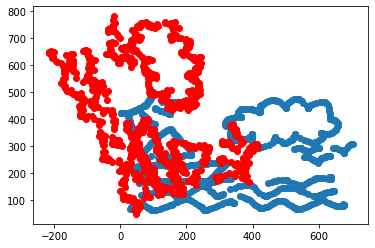

In [8]:
plt.scatter(X[0],X[1])
plt.scatter(Y[0],Y[1],color='red')

In [9]:
U,S,VT=svd(Y.dot(X.T))

In [11]:
Q = (U.dot(VT)).T

In [12]:
Y_rot = Q.dot(Y)

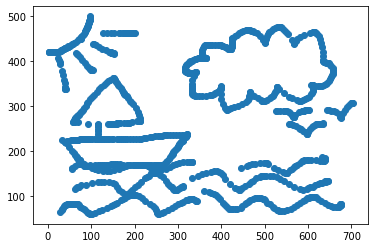

In [13]:
plt.scatter(X[0],X[1])

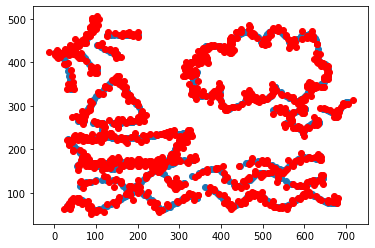

In [14]:
plt.scatter(X[0],X[1])
plt.scatter(Y_rot[0],Y_rot[1], color='red')